# Clase 8 - Aprendizaje Supervisado

## Notebook 4: Ejercicio Integrador

Alumno: Sara Valenzuela

Materia: Minería de Datos

Objetivo:

Aplicar técnicas de Regresión Logística y Regresión Múltiple en un caso práctico de una compañía de seguros para predecir la ocurrencia de reclamos y estimar el monto de los reclamos.

In [54]:
# Impoertae libreria
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

In [55]:
data = {
    "Cliente": [1, 2, 3, 4, 5, 6],
    "Edad": [25, 40, 32, 50, 28, 45],
    "Ingresos": [30000, 55000, 42000, 60000, 37000, 52000],
    "Historial_Accidentes": [1, 0, 1, 0, 1, 0],
    "Monto_Reclamo": [5000, 0, 7500, 0, 6500, 0],
    "Reclamo": ["Sí", "No", "Sí", "No", "Sí", "No"]
}

df = pd.DataFrame(data)

df

,Cliente,Edad,Ingresos,Historial_Accidentes,Monto_Reclamo,Reclamo
0,1,25,30000,1,5000,Sí
1,2,40,55000,0,0,No
2,3,32,42000,1,7500,Sí
3,4,50,60000,0,0,No
4,5,28,37000,1,6500,Sí
5,6,45,52000,0,0,No


## Exploración inicial

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Cliente               6 non-null      int64 
 1   Edad                  6 non-null      int64 
 2   Ingresos              6 non-null      int64 
 3   Historial_Accidentes  6 non-null      int64 
 4   Monto_Reclamo         6 non-null      int64 
 5   Reclamo               6 non-null      object
dtypes: int64(5), object(1)
memory usage: 420.0+ bytes


In [57]:
df.describe()

,Cliente,Edad,Ingresos,Historial_Accidentes,Monto_Reclamo
count,6.000000,6.000000,6.000000,6.000000,6.000000
mean,3.500000,36.666667,46000.000000,0.500000,3166.666667
std,1.870829,9.912954,11541.230437,0.547723,3559.026084
min,1.000000,25.000000,30000.000000,0.000000,0.000000
25%,2.250000,29.000000,38250.000000,0.000000,0.000000
50%,3.500000,36.000000,47000.000000,0.500000,2500.000000
75%,4.750000,43.750000,54250.000000,1.000000,6125.000000
max,6.000000,50.000000,60000.000000,1.000000,7500.000000


## Preprocesamiento de datos

Se convierte la variable `Reclamo` en numérica:

- 0 = No presentó reclamo.
- 1 = Sí presentó reclamo.

In [58]:
df["Reclamo"] = df["Reclamo"].map({"No": 0, "Sí": 1})

df

,Cliente,Edad,Ingresos,Historial_Accidentes,Monto_Reclamo,Reclamo
0,1,25,30000,1,5000,1
1,2,40,55000,0,0,0
2,3,32,42000,1,7500,1
3,4,50,60000,0,0,0
4,5,28,37000,1,6500,1
5,6,45,52000,0,0,0


## Visualización de la variable objetivo

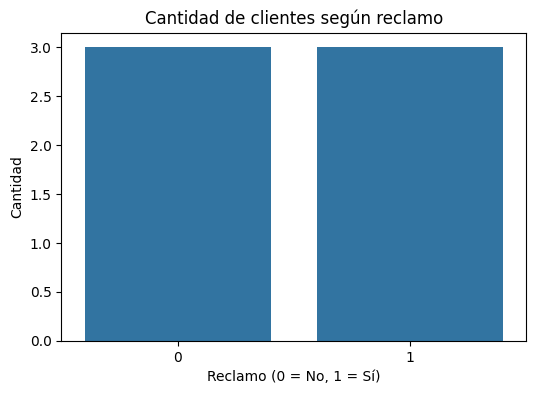

In [59]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Reclamo")

plt.title("Cantidad de clientes según reclamo")
plt.xlabel("Reclamo (0 = No, 1 = Sí)")
plt.ylabel("Cantidad")

plt.show()

Interpretación:

El dataset presenta la misma cantidad de clientes con reclamo y sin reclamo. Esto permite trabajar con clases balanceadas para el modelo de Regresión Logística.

## Definición de variables predictoras y variables objetivo

In [60]:
X = df[["Edad", "Ingresos", "Historial_Accidentes"]]

y_clasificacion = df["Reclamo"]

y_regresion = df["Monto_Reclamo"]

X

,Edad,Ingresos,Historial_Accidentes
0,25,30000,1
1,40,55000,0
2,32,42000,1
3,50,60000,0
4,28,37000,1
5,45,52000,0


## División en entrenamiento y prueba

Se divide el dataset en 80% para entrenamiento y 20% para prueba.

In [61]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X,
    y_clasificacion,
    test_size=0.2,
    random_state=42
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X,
    y_regresion,
    test_size=0.2,
    random_state=42
)

print("Entrenamiento clasificación:", X_train_c.shape)
print("Prueba clasificación:", X_test_c.shape)
print("Entrenamiento regresión:", X_train_r.shape)
print("Prueba regresión:", X_test_r.shape)

Entrenamiento clasificación: (4, 3)
Prueba clasificación: (2, 3)
Entrenamiento regresión: (4, 3)
Prueba regresión: (2, 3)


# Modelo 1: Regresión Logística

La Regresión Logística se utiliza para predecir si un cliente presentará o no un reclamo. En este caso, la variable objetivo es binaria.

In [62]:
modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(X_train_c, y_train_c)

y_pred_c = modelo_logistico.predict(X_test_c)

print("Modelo de Regresión Logística entrenado correctamente")

Modelo de Regresión Logística entrenado correctamente


## Evaluación de la Regresión Logística

In [63]:
precision = accuracy_score(y_test_c, y_pred_c)

print("Precisión:", precision)

Precisión: 1.0


In [64]:
matriz = confusion_matrix(y_test_c, y_pred_c)

print("Matriz de Confusión:")
print(matriz)

Matriz de Confusión:
[[1 0]
 [0 1]]


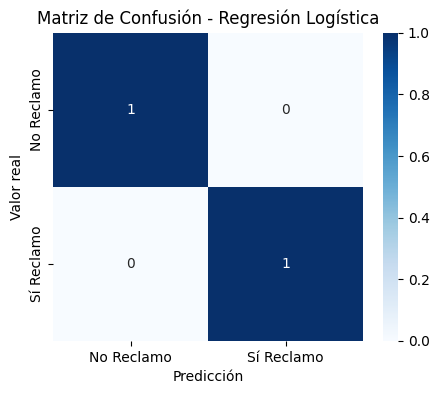

In [65]:
plt.figure(figsize=(5,4))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Reclamo", "Sí Reclamo"],
    yticklabels=["No Reclamo", "Sí Reclamo"]
)

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

In [66]:
print("Reporte de Clasificación:")
print(classification_report(y_test_c, y_pred_c))

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



Interpretación:

La Regresión Logística permite clasificar a los clientes según la probabilidad de presentar o no un reclamo. La precisión indica la proporción de predicciones correctas sobre el conjunto de prueba.

La matriz de confusión permite observar los aciertos y errores del modelo, diferenciando entre clientes correctamente clasificados y clientes clasificados de forma incorrecta.

# Modelo 2: Regresión Múltiple

La Regresión Múltiple se utiliza para estimar el monto del reclamo en dólares. En este caso, la variable objetivo es numérica continua.

In [67]:
modelo_regresion = LinearRegression()

modelo_regresion.fit(X_train_r, y_train_r)

y_pred_r = modelo_regresion.predict(X_test_r)

print("Modelo de Regresión Múltiple entrenado correctamente")

Modelo de Regresión Múltiple entrenado correctamente


## Predicciones de monto de reclamo

In [68]:
predicciones_regresion = pd.DataFrame({
    "Monto Real": y_test_r,
    "Monto Predicho": y_pred_r
})

predicciones_regresion

,Monto Real,Monto Predicho
0,5000,8071.428571
1,0,-7857.142857


## Evaluación de la Regresión Múltiple

In [69]:
r2 = r2_score(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)

print("R²:", round(r2, 4))
print("MSE:", round(mse, 2))
print("MAE:", round(mae, 2))

R²: -4.6935
MSE: 35584183.67
MAE: 5464.29


##Interpretación:

El valor de R² obtenido indica que el modelo no logra explicar adecuadamente la variabilidad del monto del reclamo en el conjunto de prueba. Esto puede deberse a que el dataset es muy pequeño y contiene pocos registros.
El MSE y el MAE permiten observar el error entre los montos reales y los montos predichos. Aunque el modelo se aplicó correctamente, los resultados deben interpretarse con precaución por el tamaño reducido de la muestra.

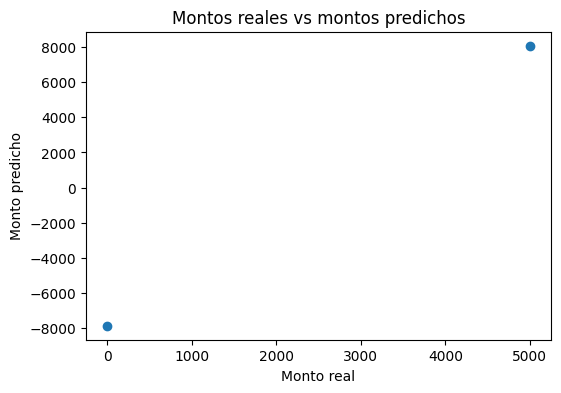

In [70]:
plt.figure(figsize=(6,4))

plt.scatter(y_test_r, y_pred_r)

plt.title("Montos reales vs montos predichos")
plt.xlabel("Monto real")
plt.ylabel("Monto predicho")

plt.show()

## Interacción con IA

Consulta sugerida:

"Tengo un dataset de aseguradoras. ¿Qué estrategias de modelado recomendarías para predecir el monto de un reclamo?"

Respuesta:

Para predecir el monto de un reclamo en un dataset de aseguradoras, se recomienda comenzar con un análisis exploratorio de los datos para identificar variables relevantes, valores faltantes y posibles valores atípicos.

Luego, se pueden aplicar modelos de regresión, como Regresión Lineal Múltiple, Árboles de Decisión o Random Forest, dependiendo del tamaño y complejidad del dataset.

También sería conveniente evaluar los modelos con métricas como R², MSE, RMSE y MAE, ya que permiten analizar la calidad de las predicciones y el nivel de error del modelo.

En este ejercicio se utiliza Regresión Múltiple porque el objetivo es estimar un monto económico, es decir, una variable numérica continua.

## Conclusión

En este ejercicio integrador se aplicaron dos modelos de aprendizaje supervisado sobre un dataset de seguros.

La Regresión Logística se utilizó para predecir si un cliente presentaría o no un reclamo, ya que la variable objetivo era categórica binaria.

La Regresión Múltiple se utilizó para estimar el monto del reclamo, debido a que la variable objetivo era numérica continua.

Las métricas utilizadas permitieron evaluar el desempeño de ambos modelos. La matriz de confusión y la precisión fueron adecuadas para el modelo de clasificación, mientras que R², MSE y MAE permitieron analizar el error del modelo de regresión.

Se concluye que la elección del modelo depende del tipo de variable que se desea predecir: clasificación para categorías y regresión para valores numéricos continuos.